In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_ds = datasets.MNIST("./data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST("./data", train=False, transform=transform)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=64)


device = "cuda" if torch.cuda.is_available() else "cpu"

model = SimpleNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

for epoch in range(3):
    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

    print(f"epoch {epoch}, loss={loss.item():.4f}")


activations = {}

def hook_fn(name):
    def hook(module, input, output):
        activations[name] = output.detach().cpu()
    return hook

model.fc1.register_forward_hook(hook_fn("fc1"))
model.fc2.register_forward_hook(hook_fn("fc2"))
model.fc3.register_forward_hook(hook_fn("fc3"))


model.eval()
x, y = next(iter(test_loader))
x = x.to(device)

with torch.no_grad():
    _ = model(x)



for name, act in activations.items():
    plt.figure()
    plt.hist(act.flatten().numpy(), bins=100)
    plt.title(f"Activations: {name}")
    plt.show()



epoch 0 done
epoch 1 done
epoch 2 done
qMax=2147483647 acc=0.9759
qMax=65536 acc=0.9759
qMax=4096 acc=0.9758
qMax=256 acc=0.9758
qMax=16 acc=0.9729
qMax=2 acc=0.4918


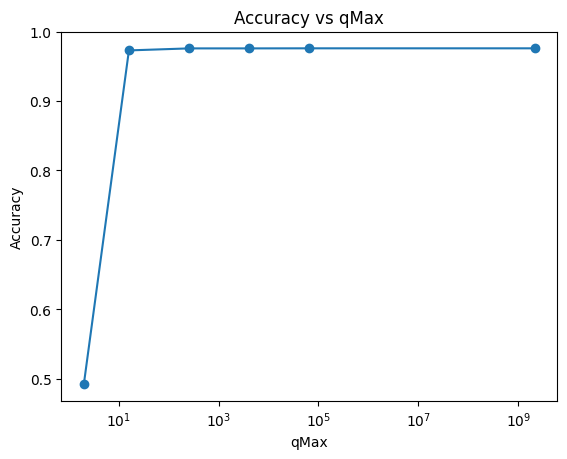

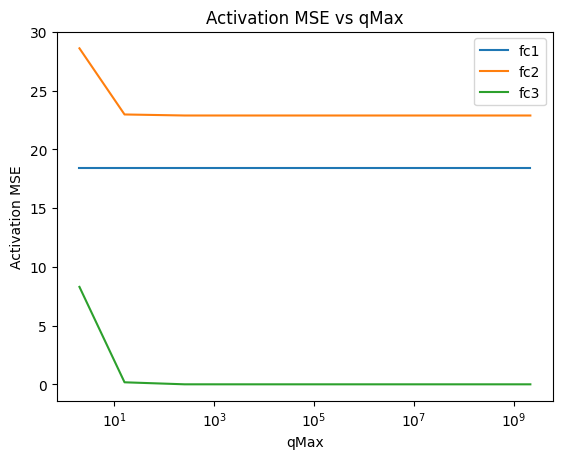

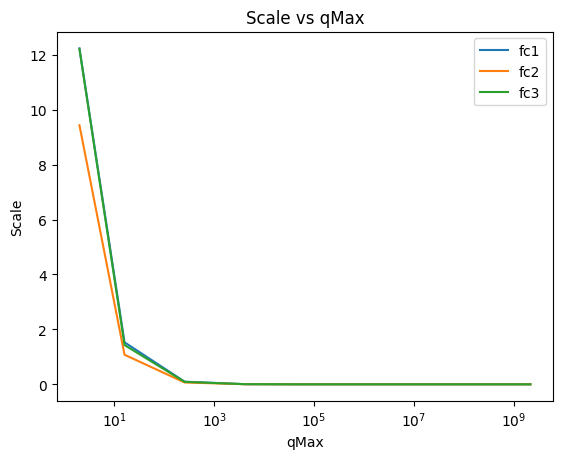

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# 1. Model
# -----------------------------
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


# -----------------------------
# 2. Symmetric int32 fake quant
# -----------------------------
def quantize_sym_int32(x, qmax):
    abs_max = x.abs().max()
    if abs_max == 0:
        scale = torch.tensor(1.0, device=x.device)
    else:
        scale = abs_max / qmax

    x_q = torch.round(x / scale)
    x_q = torch.clamp(x_q, -qmax, qmax)
    x_dq = x_q * scale
    return x_dq, scale.item()


# -----------------------------
# 3. Quantized wrapper
# -----------------------------
class QuantizedNet(nn.Module):
    def __init__(self, float_model, qmax):
        super().__init__()
        self.qmax = qmax
        self.fc1 = float_model.fc1
        self.fc2 = float_model.fc2
        self.fc3 = float_model.fc3

    def forward(self, x):
        scales = {}

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x, scales["fc1"] = quantize_sym_int32(x, self.qmax)

        x = F.relu(self.fc2(x))
        x, scales["fc2"] = quantize_sym_int32(x, self.qmax)

        x = self.fc3(x)
        x, scales["fc3"] = quantize_sym_int32(x, self.qmax)

        return x, scales


# -----------------------------
# 4. Data
# -----------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_ds = datasets.MNIST("./data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST("./data", train=False, transform=transform)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=256)

device = "cuda" if torch.cuda.is_available() else "cpu"


# -----------------------------
# 5. Train float reference
# -----------------------------
float_model = SimpleNet().to(device)
opt = torch.optim.Adam(float_model.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()

for epoch in range(3):
    float_model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        out = float_model(x)
        loss = crit(out, y)
        loss.backward()
        opt.step()

    print(f"epoch {epoch} done")


# -----------------------------
# 6. Capture float activations
# -----------------------------
float_acts = {}

def hook(name):
    def fn(_, __, out):
        float_acts[name] = out.detach()
    return fn

float_model.fc1.register_forward_hook(hook("fc1"))
float_model.fc2.register_forward_hook(hook("fc2"))
float_model.fc3.register_forward_hook(hook("fc3"))


# -----------------------------
# 7. Experiment sweep
# -----------------------------
qmax_values = [
    2**31 - 1,
    2**16,
    2**12,
    2**8,
    2**4,
    2**1,
]

results = {
    "qmax": [],
    "acc": [],
    "mse_fc1": [],
    "mse_fc2": [],
    "mse_fc3": [],
    "scale_fc1": [],
    "scale_fc2": [],
    "scale_fc3": [],
}

def mse(a, b):
    return ((a - b) ** 2).mean().item()

for qmax in qmax_values:
    qmodel = QuantizedNet(float_model, qmax).to(device)
    qmodel.eval()
    float_model.eval()

    correct = 0
    total = 0

    mse_fc1 = []
    mse_fc2 = []
    mse_fc3 = []
    scales_fc1 = []
    scales_fc2 = []
    scales_fc3 = []

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)

            _ = float_model(x)
            q_out, scales = qmodel(x)

            pred = q_out.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)

            mse_fc1.append(mse(float_acts["fc1"], qmodel.fc1(x.view(x.size(0), -1)).relu()))
            mse_fc2.append(mse(float_acts["fc2"], qmodel.fc2(float_acts["fc1"]).relu()))
            mse_fc3.append(mse(float_acts["fc3"], q_out))

            scales_fc1.append(scales["fc1"])
            scales_fc2.append(scales["fc2"])
            scales_fc3.append(scales["fc3"])

    results["qmax"].append(qmax)
    results["acc"].append(correct / total)
    results["mse_fc1"].append(np.mean(mse_fc1))
    results["mse_fc2"].append(np.mean(mse_fc2))
    results["mse_fc3"].append(np.mean(mse_fc3))
    results["scale_fc1"].append(np.mean(scales_fc1))
    results["scale_fc2"].append(np.mean(scales_fc2))
    results["scale_fc3"].append(np.mean(scales_fc3))

    print(f"qMax={qmax} acc={correct/total:.4f}")


# -----------------------------
# 8. Plots
# -----------------------------
plt.figure()
plt.semilogx(results["qmax"], results["acc"], marker="o")
plt.xlabel("qMax")
plt.ylabel("Accuracy")
plt.title("Accuracy vs qMax")
plt.show()

plt.figure()
plt.semilogx(results["qmax"], results["mse_fc1"], label="fc1")
plt.semilogx(results["qmax"], results["mse_fc2"], label="fc2")
plt.semilogx(results["qmax"], results["mse_fc3"], label="fc3")
plt.xlabel("qMax")
plt.ylabel("Activation MSE")
plt.legend()
plt.title("Activation MSE vs qMax")
plt.show()

plt.figure()
plt.semilogx(results["qmax"], results["scale_fc1"], label="fc1")
plt.semilogx(results["qmax"], results["scale_fc2"], label="fc2")
plt.semilogx(results["qmax"], results["scale_fc3"], label="fc3")
plt.xlabel("qMax")
plt.ylabel("Scale")
plt.legend()
plt.title("Scale vs qMax")
plt.show()


Epoch 1 [0/60000] Loss=2.320556
Epoch 1 [10000/60000] Loss=2.314911
Epoch 1 [20000/60000] Loss=2.290918
Epoch 1 [30000/60000] Loss=2.287803
Epoch 1 [40000/60000] Loss=2.268627
Epoch 1 [50000/60000] Loss=2.248311
Test accuracy: 41.42%
Epoch 2 [0/60000] Loss=2.232626
Epoch 2 [10000/60000] Loss=2.211702
Epoch 2 [20000/60000] Loss=2.188070
Epoch 2 [30000/60000] Loss=2.163083
Epoch 2 [40000/60000] Loss=2.083945
Epoch 2 [50000/60000] Loss=2.043474
Test accuracy: 67.73%
Epoch 3 [0/60000] Loss=1.935576
Epoch 3 [10000/60000] Loss=1.845640
Epoch 3 [20000/60000] Loss=1.734050
Epoch 3 [30000/60000] Loss=1.626891
Epoch 3 [40000/60000] Loss=1.500628
Epoch 3 [50000/60000] Loss=1.393574
Test accuracy: 81.84%
Epoch 4 [0/60000] Loss=1.350162
Epoch 4 [10000/60000] Loss=1.295905
Epoch 4 [20000/60000] Loss=1.141543
Epoch 4 [30000/60000] Loss=1.131646
Epoch 4 [40000/60000] Loss=1.132349
Epoch 4 [50000/60000] Loss=1.010778
Test accuracy: 86.38%
Epoch 5 [0/60000] Loss=1.024020
Epoch 5 [10000/60000] Loss=0.947

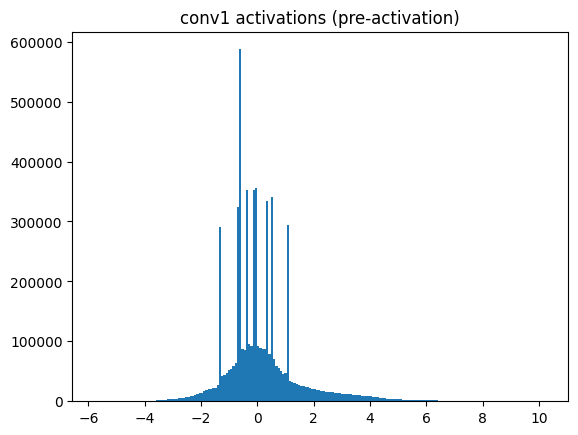

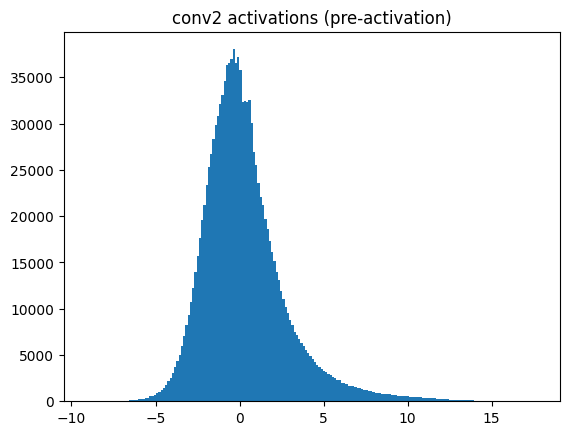

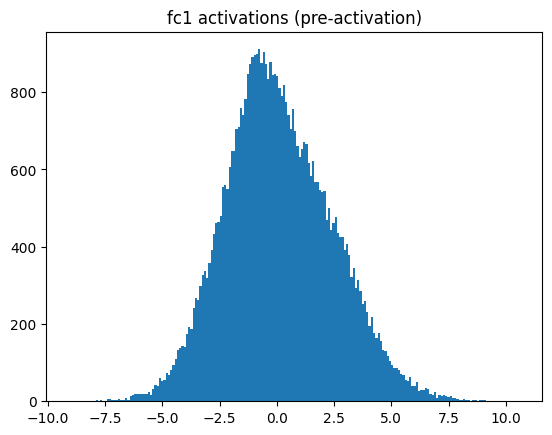

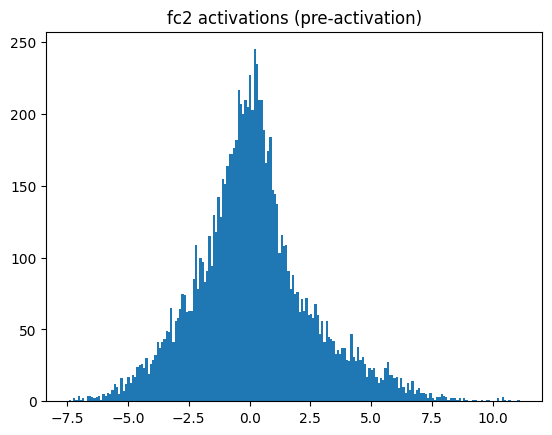

fc1: qMax=7, scale=1.515e+00, MSE=1.906093e-01
fc1: qMax=127, scale=8.349e-02, MSE=5.823898e-04
fc1: qMax=2047, scale=5.180e-03, MSE=2.229249e-06
fc1: qMax=32767, scale=3.236e-04, MSE=8.717676e-09
fc1: qMax=2147483647, scale=4.937e-09, MSE=4.333418e-15
fc1: qMax=9223372036854775807, scale=1.150e-18, MSE=4.333373e-15


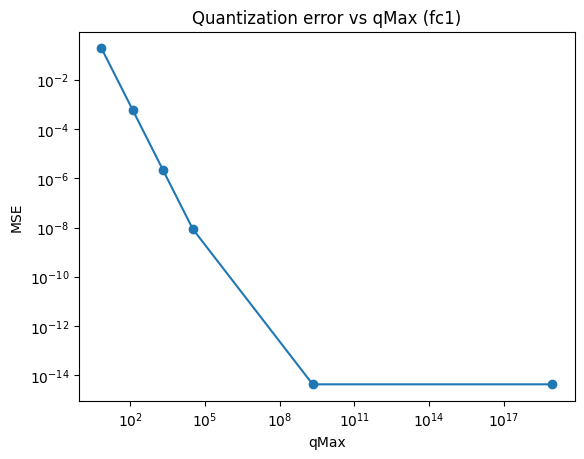

In [17]:
from __future__ import print_function
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

batch_size = 1000
test_batch_size = 1000
epochs = 5
lr = 0.01
momentum = 0.5
cuda = False

device = torch.device("cuda" if cuda and torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=True, download=True, transform=transform),
    batch_size=batch_size, shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=False, transform=transform),
    batch_size=test_batch_size, shuffle=False
)

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.conv2_drop = nn.Dropout2d()
        self.fc1 = nn.Linear(320, 50)
        self.fc2 = nn.Linear(50, 10)

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2_drop(self.conv2(x)), 2))
        x = x.view(-1, 320)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, training=self.training)
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

model = Net().to(device)
optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum)

def train(epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.nll_loss(output, target)
        loss.backward()
        optimizer.step()

        if batch_idx % 10 == 0:
            print(f"Epoch {epoch} [{batch_idx*len(data)}/{len(train_loader.dataset)}] "
                  f"Loss={loss.item():.6f}")

def test():
    model.eval()
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()

    acc = 100. * correct / len(test_loader.dataset)
    print(f"Test accuracy: {acc:.2f}%")

for epoch in range(1, epochs + 1):
    train(epoch)
    test()

activations = {}

def hook_fn(name):
    def hook(module, input, output):
        activations[name] = output.detach().cpu()
    return hook

model.conv1.register_forward_hook(hook_fn("conv1"))
model.conv2.register_forward_hook(hook_fn("conv2"))
model.fc1.register_forward_hook(hook_fn("fc1"))
model.fc2.register_forward_hook(hook_fn("fc2"))

model.eval()
with torch.no_grad():
    data, target = next(iter(test_loader))
    data = data.to(device)
    _ = model(data)
    
for name, act in activations.items():
    plt.figure()
    plt.hist(act.flatten().numpy(), bins=200)
    plt.title(f"{name} activations (pre-activation)")
    plt.show()

def int32_quant(x, qmax):
    abs_max = x.abs().max()
    if abs_max == 0:
        return x, 1.0

    scale = abs_max / qmax
    x_q = torch.clamp(torch.round(x / scale), -qmax, qmax)
    x_dq = x_q * scale
    return x_dq, scale

layer_name = "fc1"
x = activations[layer_name]

qmax_values = [2**3-1, 2**7-1, 2**11-1, 2**15-1, 2**31-1, 2**63-1]
errors = []

for qmax in qmax_values:
    x_q, scale = int32_quant(x, qmax)
    mse = torch.mean((x - x_q) ** 2).item()
    errors.append(mse)
    print(f"{layer_name}: qMax={qmax}, scale={scale:.3e}, MSE={mse:.6e}")

plt.figure()
plt.plot(qmax_values, errors, marker='o')
plt.xscale("log")
plt.yscale("log")
plt.xlabel("qMax")
plt.ylabel("MSE")
plt.title(f"Quantization error vs qMax ({layer_name})")
plt.show()
